In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.7MB/s]


In [3]:
latent_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.view(-1, 784))


In [4]:
num_generators = 3  # Evolutionary population

generators = [Generator().to(device) for _ in range(num_generators)]
discriminator = Discriminator().to(device)

g_optimizers = [optim.Adam(g.parameters(), lr=0.0002) for g in generators]
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)

loss_fn = nn.BCELoss()


In [18]:
epochs = 25

for epoch in range(epochs):
    for real_imgs, _ in train_loader:

        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =====================
        # Train Discriminator
        # =====================
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = generators[0](z)  # use best generator temporarily

        real_loss = loss_fn(discriminator(real_imgs), real_labels)
        fake_loss = loss_fn(discriminator(fake_imgs.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # =====================
        # Train ALL Generators (Mutation)
        # =====================
        g_losses = []

        for i, gen in enumerate(generators):
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_imgs = gen(z)
            g_loss = loss_fn(discriminator(fake_imgs), real_labels)

            g_optimizers[i].zero_grad()
            g_loss.backward()
            g_optimizers[i].step()

            g_losses.append(g_loss.item())

        # =====================
        # SELECTION: Keep Best Generator
        # =====================
        best_idx = np.argmin(g_losses)
        best_generator = generators[best_idx]

        generators = [best_generator] + generators[1:]

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | Best G Loss: {min(g_losses):.4f}")


Epoch [1/25] | D Loss: 0.2918 | Best G Loss: 2.8891
Epoch [2/25] | D Loss: 0.5557 | Best G Loss: 2.7888
Epoch [3/25] | D Loss: 0.3903 | Best G Loss: 3.0728
Epoch [4/25] | D Loss: 0.1921 | Best G Loss: 5.2353
Epoch [5/25] | D Loss: 0.4729 | Best G Loss: 3.7864
Epoch [6/25] | D Loss: 0.4847 | Best G Loss: 4.1140
Epoch [7/25] | D Loss: 0.4515 | Best G Loss: 2.9975
Epoch [8/25] | D Loss: 0.3070 | Best G Loss: 2.6032
Epoch [9/25] | D Loss: 0.3691 | Best G Loss: 3.1502
Epoch [10/25] | D Loss: 0.2808 | Best G Loss: 4.2964
Epoch [11/25] | D Loss: 0.4443 | Best G Loss: 4.2606
Epoch [12/25] | D Loss: 0.3379 | Best G Loss: 6.3464
Epoch [13/25] | D Loss: 0.4189 | Best G Loss: 3.5480
Epoch [14/25] | D Loss: 0.2224 | Best G Loss: 3.6669
Epoch [15/25] | D Loss: 0.6093 | Best G Loss: 2.2633
Epoch [16/25] | D Loss: 0.2368 | Best G Loss: 5.1378
Epoch [17/25] | D Loss: 0.1861 | Best G Loss: 4.1464
Epoch [18/25] | D Loss: 0.3545 | Best G Loss: 3.6725
Epoch [19/25] | D Loss: 0.3728 | Best G Loss: 3.9906
Ep

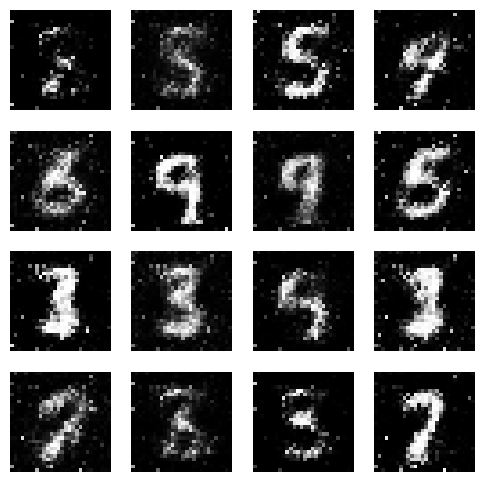

In [19]:
z = torch.randn(16, latent_dim).to(device)
samples = generators[0](z).detach().cpu()

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i][0], cmap="gray")
    plt.axis("off")
plt.show()
